<a href="https://colab.research.google.com/github/Olya-Shulga/Univercity/blob/main/neural_networks/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9F%D0%BE%D1%81%D1%82%D1%80%D0%BE%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%BE%D0%B9_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D0%BE%D0%B9_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_%D0%B4%D0%BB%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9%2C_%D1%81_%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%D0%BC_BatchNormalization()_%D0%B8_Dropout()_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()**

## **Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():**



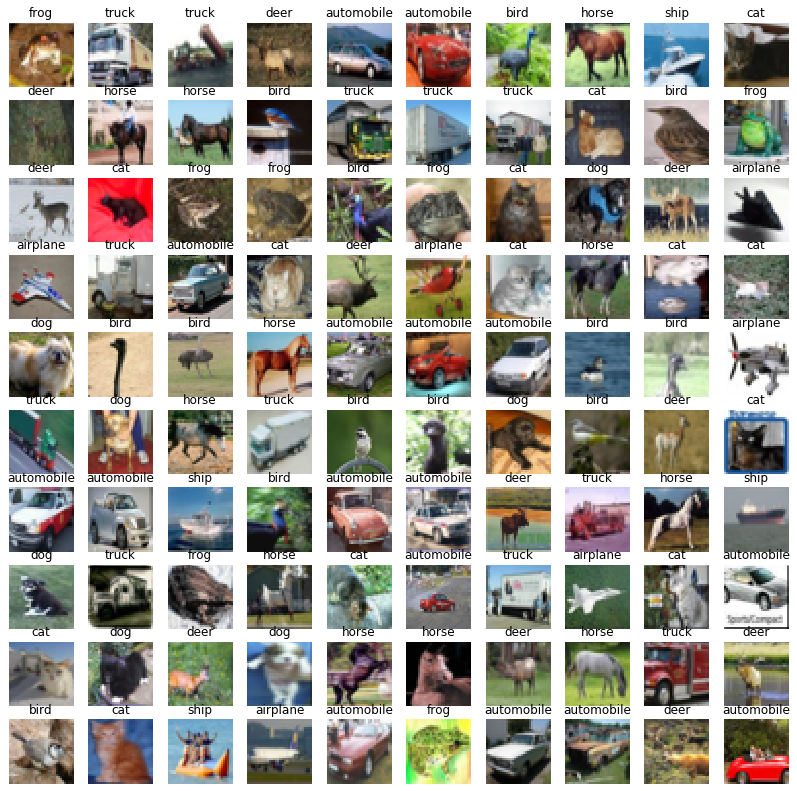

### **1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:**



*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

[Техническая документация по использованию датасета в Keras](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar100/load_data)





In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import warnings
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (
    Activation, BatchNormalization, Conv2D, Dense,
    Dropout, Flatten, MaxPooling2D
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [3]:
from tensorflow.keras.datasets import cifar100

(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

print('Train shape:', x_train.shape)
print('Test shape:', x_test.shape)
print('y_train shape:', y_train.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
y_train shape: (50000, 1)


### **1.2. Визуализируйте несколько изображений из датасета:**


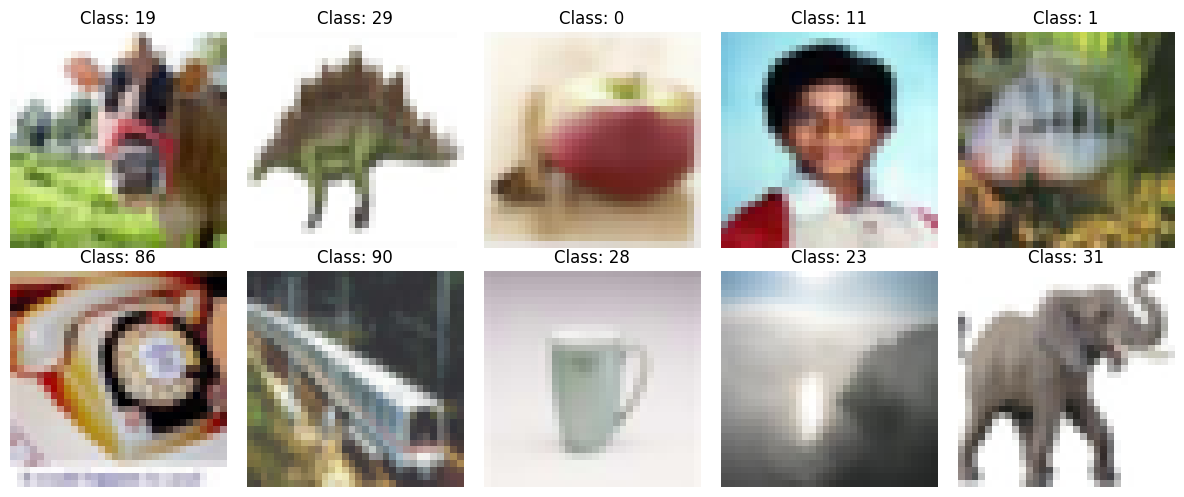

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(x_train[i])
    ax.set_title(f'Class: {y_train[i][0]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### **1.3. Произведите нормализацию данных:**

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

### **1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():**

Имя данной модели: model_1

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

In [7]:
model_1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(100, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Обучите созданную модель

In [8]:
model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model_1.fit(x_train, y_train,
                       epochs=50,
                       batch_size=128,
                       validation_split=0.2,
                       callbacks=get_callbacks('model_1'),
                       verbose=1)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0508 - loss: 4.2803
Epoch 1: val_accuracy improved from None to 0.14930, saving model to best_model_1.keras

Epoch 1: finished saving model to best_model_1.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.0910 - loss: 3.9933 - val_accuracy: 0.1493 - val_loss: 3.6101 - learning_rate: 0.0010
Epoch 2/50
309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1814 - loss: 3.4277
Epoch 2: val_accuracy improved from 0.14930 to 0.22450, saving model to best_model_1.keras

Epoch 2: finished saving model to best_model_1.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2001 - loss: 3.3210 - val_accuracy: 0.2245 - val_loss: 3.1717 - learning_rate: 0.0010
Epoch 3/50
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2517 - loss: 3.0371
Epoch 3: val_accuracy improved from 0.22450 to 0.26600, saving model to best_model_1.keras

Epoch 3: finished saving model to best_model_1.keras
313/313 ━━━━━━━━━━━━━━━━━

### **1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():**

Имя данной модели: model_2

In [9]:
from tensorflow.keras.layers import BatchNormalization

model_2 = Sequential([
    Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),

    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dense(100, activation='softmax')
])

Обучите созданную модель

In [10]:
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model_2.fit(x_train, y_train,
                       epochs=50,
                       batch_size=128,
                       validation_split=0.2,
                       callbacks=get_callbacks('model_2'),
                       verbose=1)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1777 - loss: 3.5836
Epoch 1: val_accuracy improved from None to 0.06330, saving model to best_model_2.keras

Epoch 1: finished saving model to best_model_2.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.2542 - loss: 3.1052 - val_accuracy: 0.0633 - val_loss: 4.8254 - learning_rate: 0.0010
Epoch 2/50
309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4376 - loss: 2.1870
Epoch 2: val_accuracy improved from 0.06330 to 0.30600, saving model to best_model_2.keras

Epoch 2: finished saving model to best_model_2.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4413 - loss: 2.1671 - val_accuracy: 0.3060 - val_loss: 2.8273 - learning_rate: 0.0010
Epoch 3/50
308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5594 - loss: 1.6786
Epoch 3: val_accuracy improved from 0.30600 to 0.34800, saving model to best_model_2.keras

Epoch 3: finished saving model to best_model_2.keras
313/313 ━━━━━━━━━━━━━━━━

### **1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():**

Имя данной модели: model_3

In [11]:
model_3 = Sequential([
    Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same'),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same'),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Flatten(),
    Dense(512),
    Activation('relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Обучите созданную модель

In [12]:
history_3 = model_3.fit(x_train, y_train,
                       epochs=50,
                       batch_size=128,
                       validation_split=0.2,
                       callbacks=get_callbacks('model_3'),
                       verbose=1)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0283 - loss: 4.4398
Epoch 1: val_accuracy improved from None to 0.12950, saving model to best_model_3.keras

Epoch 1: finished saving model to best_model_3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.0508 - loss: 4.2419 - val_accuracy: 0.1295 - val_loss: 3.8015 - learning_rate: 0.0010
Epoch 2/50
309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1205 - loss: 3.7526
Epoch 2: val_accuracy improved from 0.12950 to 0.20620, saving model to best_model_3.keras

Epoch 2: finished saving model to best_model_3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1348 - loss: 3.6693 - val_accuracy: 0.2062 - val_loss: 3.3307 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1842 - loss: 3.3921
Epoch 3: val_accuracy improved from 0.20620 to 0.24630, saving model to best_model_3.keras

Epoch 3: finished saving model to best_model_3.keras
313/313 ━━━━━━━━━━━━━━━━━

### **1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().**

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [13]:
model_4 = Sequential([
    Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Обучите созданную модель

In [14]:
history_4 = model_4.fit(x_train, y_train,
                       epochs=50,
                       batch_size=128,
                       validation_split=0.2,
                       callbacks=get_callbacks('model_4'),
                       verbose=1)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0713 - loss: 4.3747
Epoch 1: val_accuracy improved from None to 0.03950, saving model to best_model_4.keras

Epoch 1: finished saving model to best_model_4.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.1110 - loss: 3.9741 - val_accuracy: 0.0395 - val_loss: 5.1136 - learning_rate: 0.0010
Epoch 2/50
309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1987 - loss: 3.3216
Epoch 2: val_accuracy improved from 0.03950 to 0.20960, saving model to best_model_4.keras

Epoch 2: finished saving model to best_model_4.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2137 - loss: 3.2488 - val_accuracy: 0.2096 - val_loss: 3.3827 - learning_rate: 0.0010
Epoch 3/50
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2621 - loss: 2.9663
Epoch 3: val_accuracy improved from 0.20960 to 0.28250, saving model to best_model_4.keras

Epoch 3: finished saving model to best_model_4.keras
313/313 ━━━━━━━━━━━━━━━━

### **Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:**

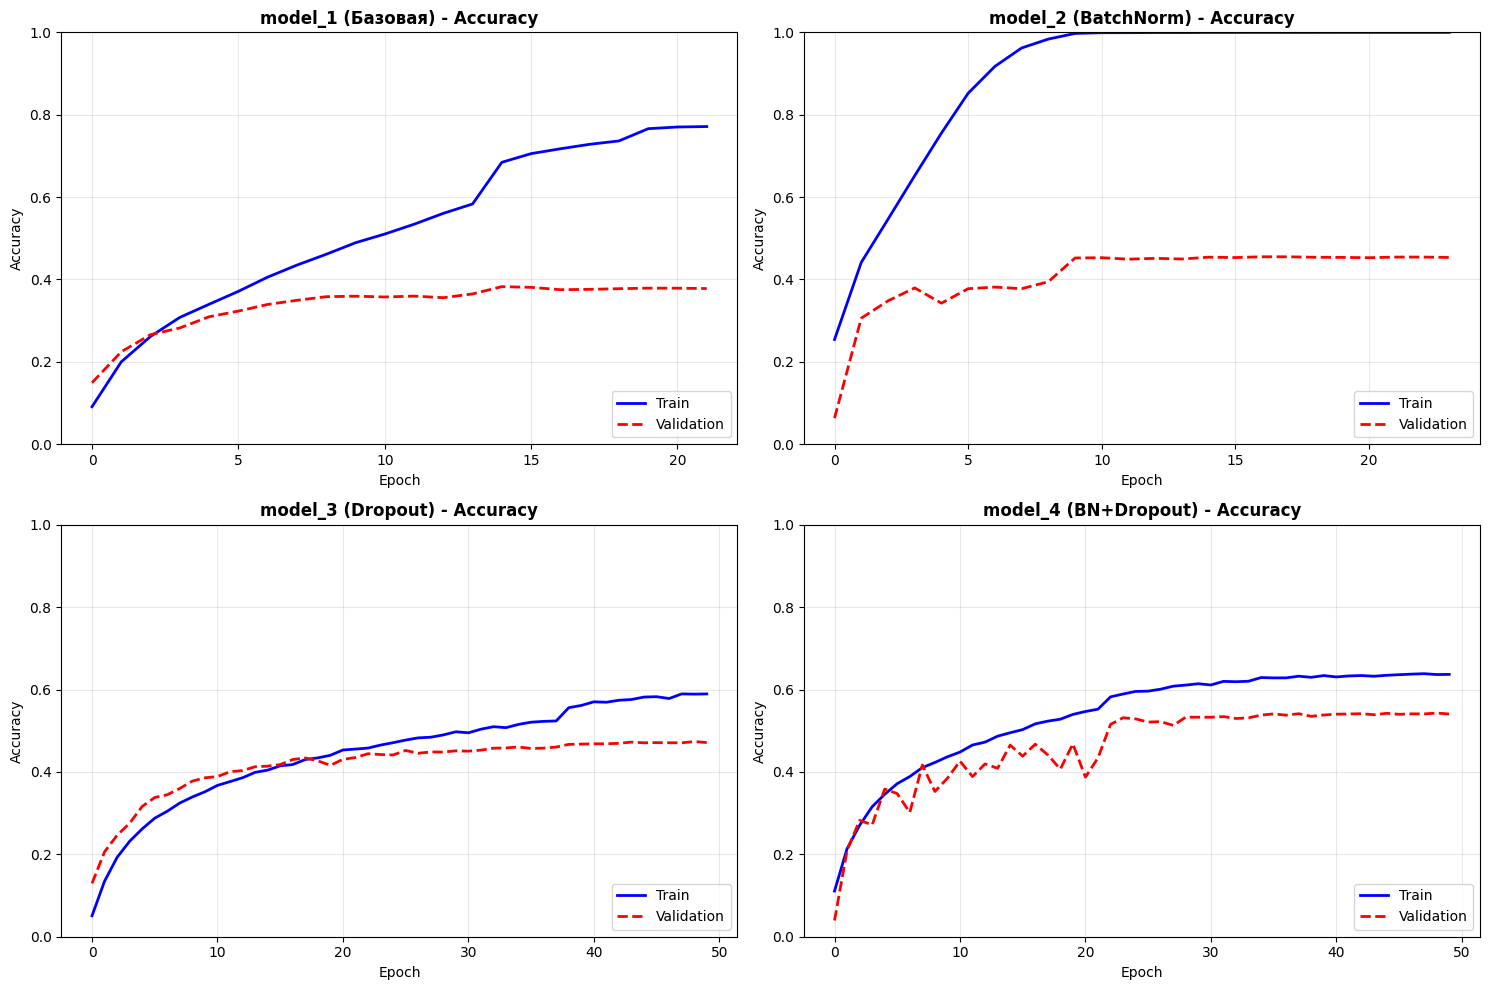

In [15]:
import matplotlib.pyplot as plt

def plot_training_history(histories, titles):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()  # Делаем оси одномерными для удобной индексации

    for i, (history, title) in enumerate(zip(histories, titles)):
        ax = axes[i]

        # Accuracy
        ax.plot(history.history['accuracy'], 'b-', label='Train', linewidth=2)
        ax.plot(history.history['val_accuracy'], 'r--', label='Validation', linewidth=2)
        ax.set_title(f'{title} - Accuracy', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Accuracy', fontsize=10)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.0])

    plt.tight_layout()
    plt.show()

# Построить графики для всех 4 моделей
plot_training_history([history_1, history_2, history_3, history_4],
                     ['model_1 (Базовая)', 'model_2 (BatchNorm)',
                      'model_3 (Dropout)', 'model_4 (BN+Dropout)'])

Вывод на основе графиков:

Model_1: Базовая модель без регуляризации быстро переобучается

Model_2: BatchNormalization ускорила обучение, но без Dropout модель «запомнила» данные

Model_3: Dropout эффективно борется с переобучением. Кривые идут параллельно — модель обобщает, а не запоминает

Model_4: Комбинация BatchNormalization + Dropout дала лучший результат. Валидационная точность выше, чем у чистого Dropout

Итог: Комбинация BatchNorm + Dropout работает лучше, чем каждый метод по отдельности

### **1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):**

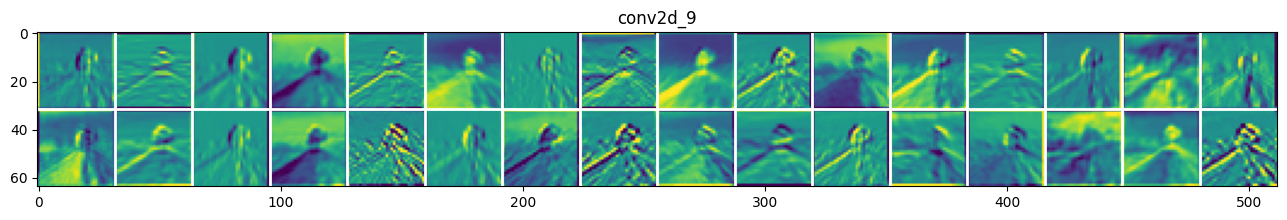

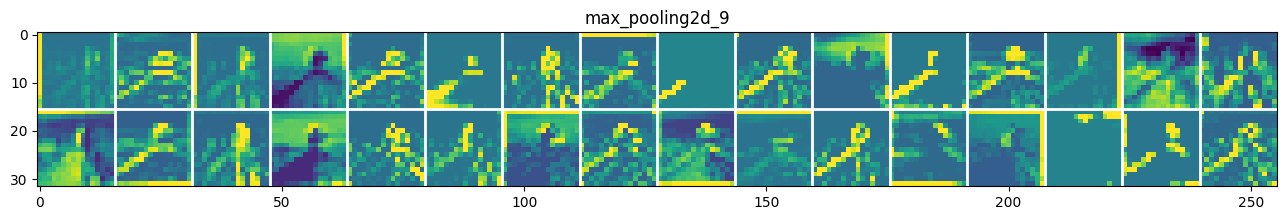

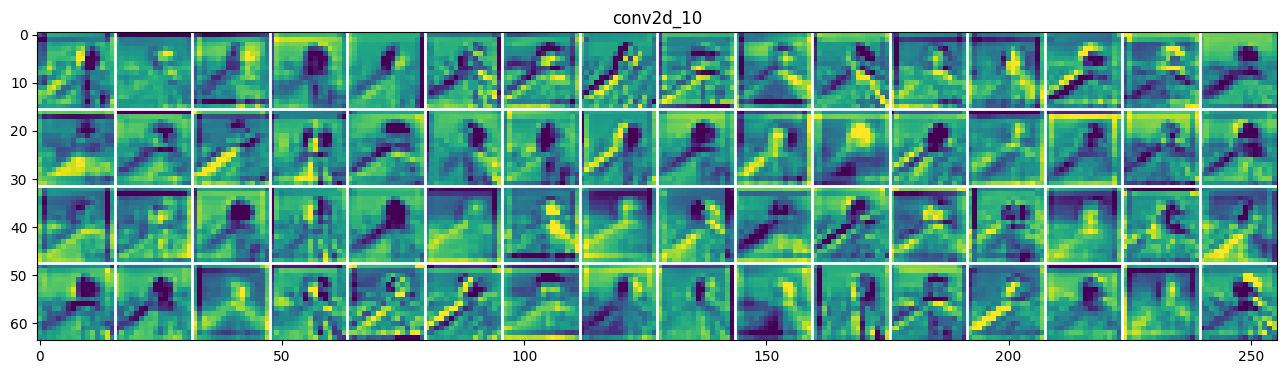

/tmp/ipykernel_752/3265272725.py:45: RuntimeWarning: divide by zero encountered in divide
  channel_image /= channel_image.std()


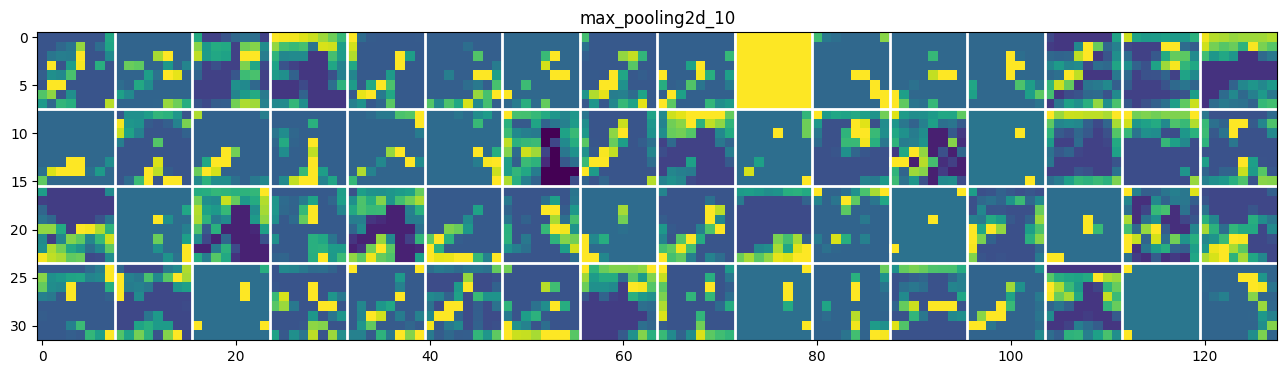

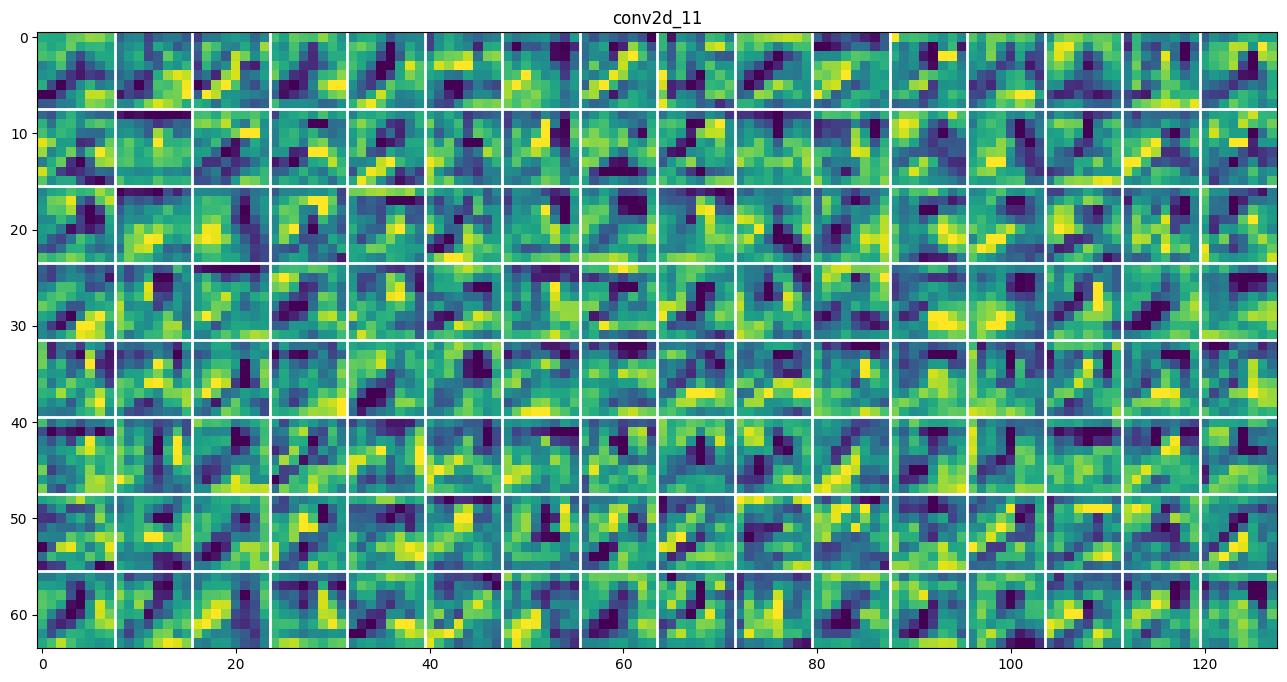

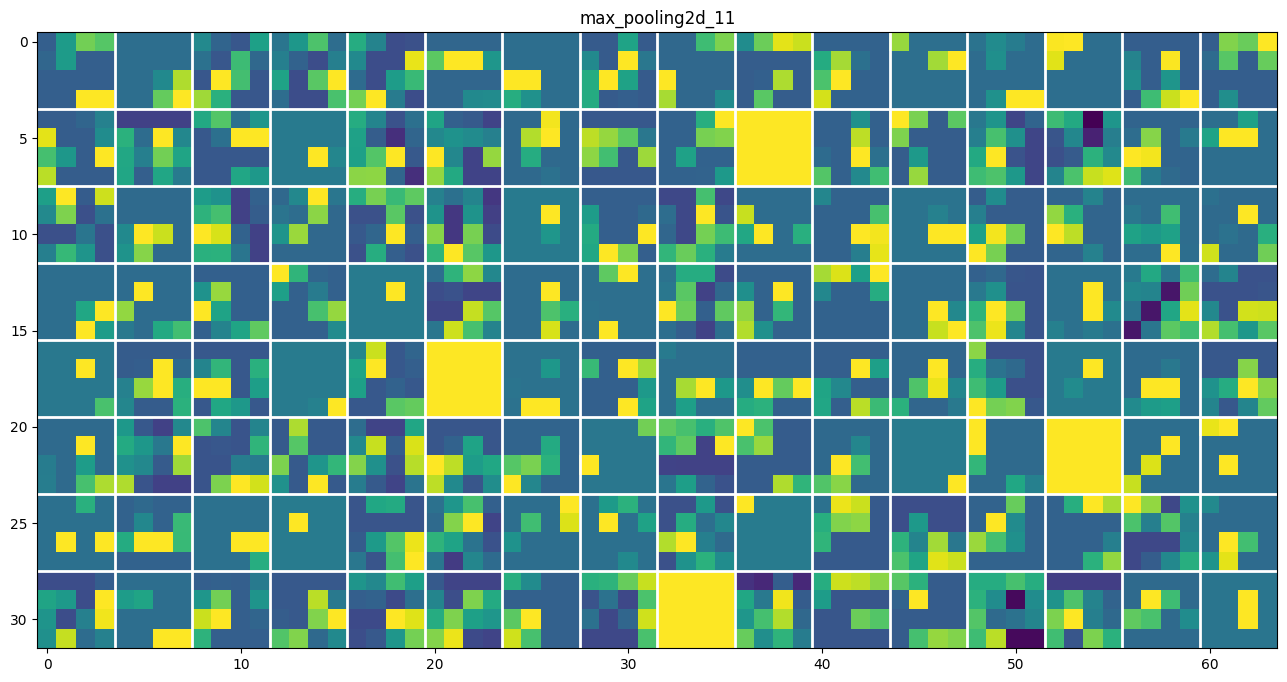

In [16]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def visualize_act_map(model, img):
    """
    Универсальная визуализация карт активаций.
    """
    target_types = (tf.keras.layers.Conv2D,
                    tf.keras.layers.MaxPooling2D,
                    tf.keras.layers.AveragePooling2D)

    # Прогоняем данные послойно, собирая активации целевых слоёв
    target_names = []
    activations = []

    x = img[:1]  # берём один пример
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, target_types):
            target_names.append(layer.name)
            activations.append(x.numpy() if hasattr(x, 'numpy') else np.array(x))

    if not activations:
        print("В модели нет свёрточных/пулинг-слоёв для визуализации.")
        return

    # Визуализация
    for layer_name, layer_activation in zip(target_names, activations):
        n_features = layer_activation.shape[-1]
        size = layer_activation.shape[1]
        n_cols = n_features // 16 + int(n_features % 16 > 0)
        display_grid = np.zeros((size * n_cols, size * 16))

        for col in range(n_cols):
            for row in range(16):
                idx = col * 16 + row
                if idx >= n_features:
                    continue
                channel_image = layer_activation[0, :, :, idx].copy()
                channel_image -= channel_image.mean()
                std = channel_image.std()
                if std == 0:
                    channel_image += 1e-8
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                display_grid[col * size:(col + 1) * size,
                             row * size:(row + 1) * size] = channel_image

        scale = 1. / size
        fig, ax = plt.subplots(figsize=(scale * display_grid.shape[1],
                                         scale * display_grid.shape[0]))
        ax.set_title(layer_name)
        ax.grid(False)
        ax.imshow(display_grid, aspect='auto', cmap='viridis')

        for i in range(1, n_cols):
            ax.axhline(y=i * size - 0.5, color='white', linewidth=2)
        for i in range(1, 16):
            ax.axvline(x=i * size - 0.5, color='white', linewidth=2)

        plt.show()


visualize_act_map(model_4, x_test)

## **Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.**

In [17]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import Dense, Conv2D
from keras.optimizers import SGD, Adam
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import random
import pickle
import cv2
import os
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization, Activation, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
DATASET_PATH = "/content/drive/MyDrive/my_photos"
IMAGE_SIZE = (128, 128)
# Инициализация данных
data = []
labels = []

# Перебор классов
class_names = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {class_names}")

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    image_paths = list(paths.list_images(class_path))

    # Берем первые 1010 изображений каждого класса
    image_paths = image_paths[:1010]

    for img_path in image_paths:
        # Загрузка и предобработка
        image = cv2.imread(img_path)
        image = cv2.resize(image, IMAGE_SIZE)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        data.append(image)
        labels.append(class_name)

print(f"Загружено {len(data)} изображений")

Классы: ['cat', 'dog', 'horse']
Загружено 3030 изображений


In [20]:
# Нормализация в [0, 1]
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)
print(f"Форма данных: {data.shape}, метки: {labels.shape}")

(trainX, testX, trainY, testY) = train_test_split(data, labels,
                                                  test_size=0.25,
                                                  stratify=labels,
                                                  random_state=42)

lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)

print(f"Обучающая выборка: {trainX.shape}")
print(f"Тестовая выборка: {testX.shape}")

Форма данных: (3030, 128, 128, 3), метки: (3030,)
Обучающая выборка: (2272, 128, 128, 3)
Тестовая выборка: (758, 128, 128, 3)


In [21]:
model = Sequential([
    # Блок 1
    Conv2D(16, (3, 3), padding='same', input_shape=(128,128,3),
           kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Блок 2
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Блок 3
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Полносвязные слои
    Flatten(),
    Dense(128, kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_v2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    trainX, trainY,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks = callbacks,
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.3487 - loss: 5.5671
Epoch 1: val_accuracy improved from None to 0.34505, saving model to best_model_v2.keras

Epoch 1: finished saving model to best_model_v2.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3500 - loss: 5.5606 - val_accuracy: 0.3451 - val_loss: 5.1555 - learning_rate: 1.0000e-04
Epoch 2/100
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3475 - loss: 5.4677
Epoch 2: val_accuracy improved from 0.34505 to 0.37363, saving model to best_model_v2.keras

Epoch 2: finished saving model to best_model_v2.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.3649 - loss: 5.4215 - val_accuracy: 0.3736 - val_loss: 5.1418 - learning_rate: 1.0000e-04
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3921 - loss: 5.3207
Epoch 3: val_accuracy did not improve from 0.37363
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3957 - loss: 5.2901 - val_accuracy: 0.3275 - val_loss: 5.

In [23]:
# Оценка модели
test_loss, test_accuracy = model.evaluate(testX, testY, verbose=0)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

# Предсказания
predictions = model.predict(testX)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(testY, axis=1)

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes,
                          target_names=lb.classes_))

Точность на тестовой выборке: 0.6755
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

Classification Report:
              precision    recall  f1-score   support

         cat       0.67      0.67      0.67       252
         dog       0.68      0.43      0.53       253
       horse       0.68      0.92      0.79       253

    accuracy                           0.68       758
   macro avg       0.67      0.68      0.66       758
weighted avg       0.67      0.68      0.66       758



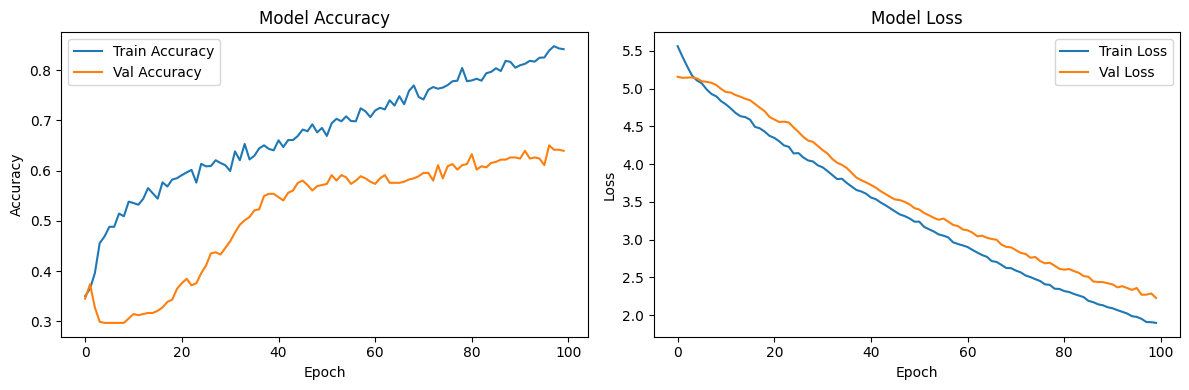

In [24]:
# Визуализация истории обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

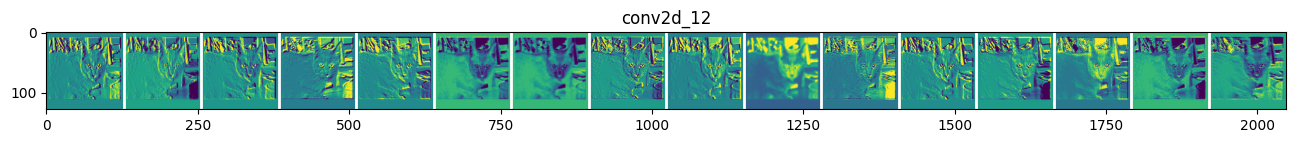

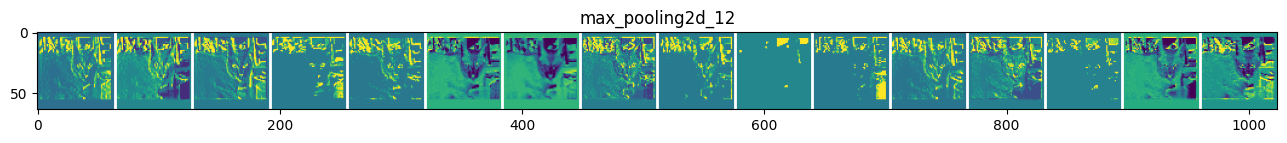

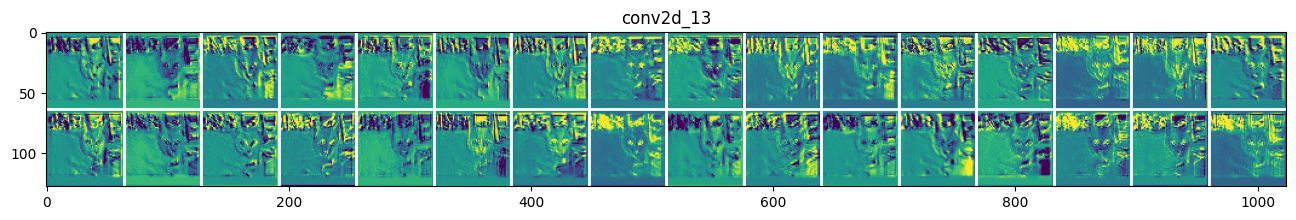

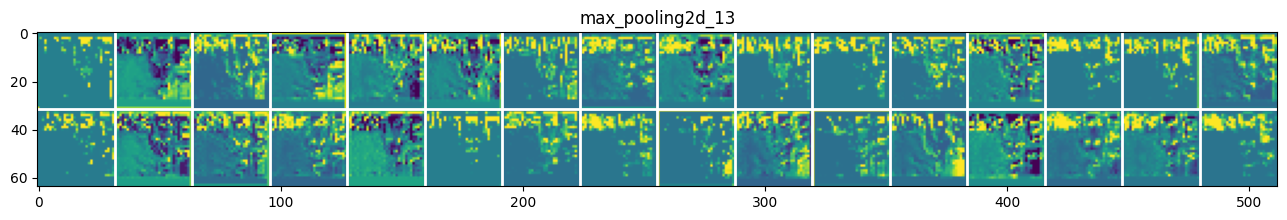

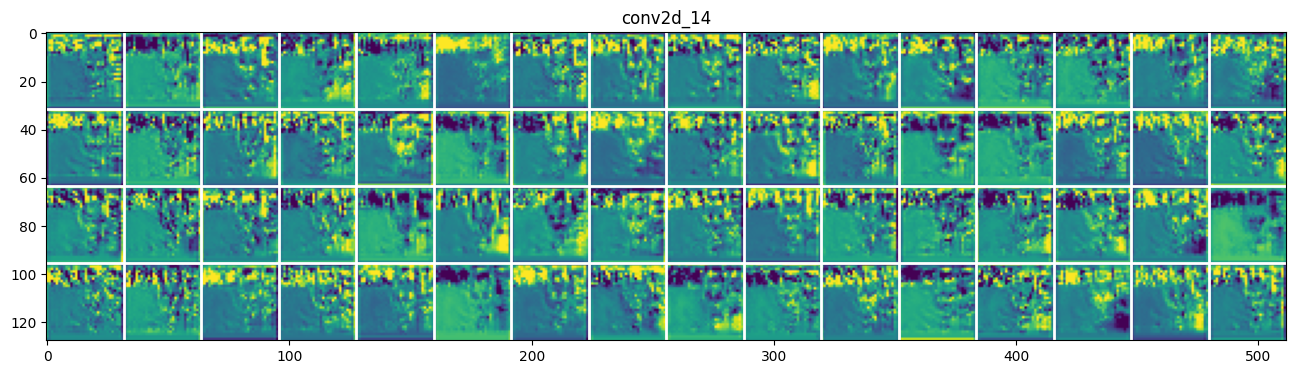

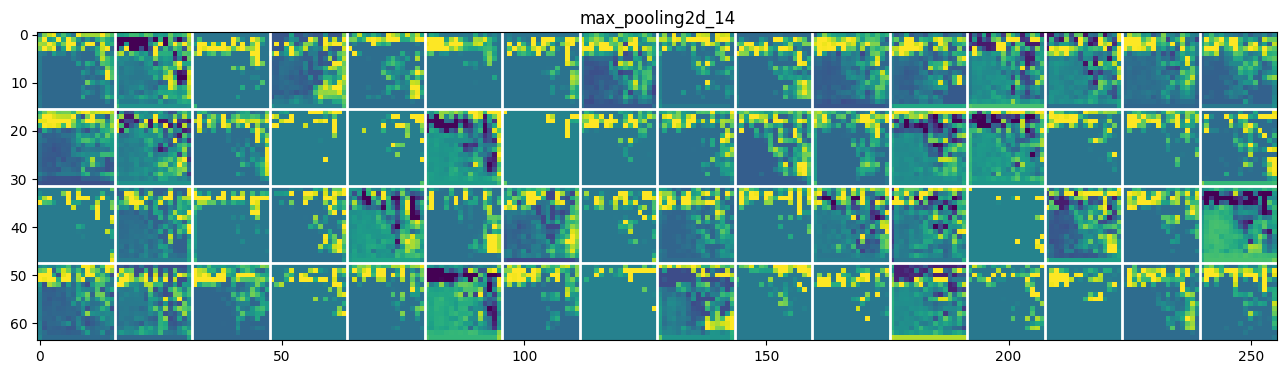

In [25]:
image_index = 0
selected_image = testX[image_index]
prediction = model.predict(np.expand_dims(selected_image, axis=0), verbose=0)
predicted_class = lb.classes_[np.argmax(prediction)]
confidence = np.max(prediction)

img_batch = np.expand_dims(selected_image, axis=0)
visualize_act_map(model, img_batch)